<a href="https://colab.research.google.com/github/gmauricio-toledo/tda/blob/main/notebooks/03-Homolog%C3%ADa_Persistente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Homología Persistente</h1>

En esta notebook experimentaremos con la Homología Persistente. Primero ilustraremos las coordenadas baricéntricas para definir puntos dentro de simplejos. Posteriormente, construimos los complejos de Cech y Vietoris-Rips.

# Simplejos y coordenadas baricéntricas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Definición de los puntos
a0 = np.array([0, 0])
a1 = np.array([1, -0.5])
a2 = np.array([0.3, 1])
puntos = np.array([a0, a1, a2])

def graficar_punto(t0, t1):
    t2 = 1 - t0 - t1
    punto = t0 * a0 + t1 * a1 + t2 * a2

    plt.figure(figsize=(8, 6))
    plt.scatter(puntos[:, 0], puntos[:, 1], c='blue', label='Vértices')
    if t2>=0:
        plt.scatter(punto[0], punto[1], c='green', label='Punto')
    else:
        plt.scatter(punto[0], punto[1], c='red', label='Punto')
    plt.fill(puntos[:, 0], puntos[:, 1], alpha=0.3, color='lightblue')  # Rellenar el triángulo
    plt.plot([puntos[0, 0], puntos[1, 0], puntos[2, 0], puntos[0, 0]],
             [puntos[0, 1], puntos[1, 1], puntos[2, 1], puntos[0, 1]], 'b-')  # Dibujar el triángulo
    plt.title(f't0={t0:.2f}, t1={t1:.2f}, t2={t2:.2f}')
    plt.legend()
    plt.axis('equal')
    plt.show()

# Sliders para t0 y t1
interact(
    graficar_punto,
    t0=FloatSlider(min=0, max=1, step=0.01, value=0.3, description='t0:'),
    t1=FloatSlider(min=0, max=1, step=0.01, value=0.4, description='t1:')
)

# Complejos Simpliciales

In [ ]:
!pip install gudhi

Ejemplo 1: Circulo con ruido

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ejemplo 1: Círculo ruidoso
theta = np.linspace(0, 2*np.pi, 30)
X = np.column_stack([np.cos(theta), np.sin(theta)])
X += np.random.normal(0, 0.1, X.shape)
print(X.shape)

plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.show()

Ejemplo 2: Dos círculos concéntricos con ruido

In [ ]:
import gudhi
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_inner, n_outer = 30, 40

theta_inner = np.linspace(0, 2*np.pi, n_inner, endpoint=False)
X_inner = 0.5 * np.column_stack([np.cos(theta_inner), np.sin(theta_inner)])
X_inner += np.random.normal(0, 0.05, X_inner.shape)

theta_outer = np.linspace(0, 2*np.pi, n_outer, endpoint=False)
X_outer = 1.5 * np.column_stack([np.cos(theta_outer), np.sin(theta_outer)])
X_outer += np.random.normal(0, 0.05, X_outer.shape)

X = np.vstack([X_inner, X_outer])

print(X.shape)

plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal')
plt.axis('off')
plt.show()

## Complejos Simpliciales: Cech y Vietoris-Rips

In [ ]:
# Construir y visualizar para diferentes epsilons
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
epsilons = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]

for ax, eps in zip(axes.flat, epsilons):
    rips = gudhi.RipsComplex(points=X, max_edge_length=eps)
    st = rips.create_simplex_tree(max_dimension=2)

    ax.scatter(X[:, 0], X[:, 1], c='black', s=30, zorder=3, alpha=0.6)

    # Aristas
    for simplex in st.get_simplices():
        if len(simplex[0]) == 2:
            i, j = simplex[0]
            ax.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]],
                   'b-', alpha=0.2, linewidth=0.8)

    # Contar componentes y ciclos
    n_edges = sum(1 for s in st.get_simplices() if len(s[0]) == 2)
    n_triangles = sum(1 for s in st.get_simplices() if len(s[0]) == 3)

    # Rellenar triángulos (2-simplejos)
    for simplex in st.get_simplices():
        if len(simplex[0]) == 3:
            i, j, k = simplex[0]
            triangle = plt.Polygon(X[[i,j,k]], alpha=0.15, color='lightblue')
            ax.add_patch(triangle)

    ax.set_title(f'ε={eps}: {n_edges} aristas, {n_triangles} triángulos')
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt
import gudhi

def visualizar_rips(epsilon):
    """Visualiza el complejo de Rips para un valor de epsilon dado"""
    fig, ax = plt.subplots()

    # Crear el complejo de Rips
    rips = gudhi.RipsComplex(points=X, max_edge_length=epsilon)
    st = rips.create_simplex_tree(max_dimension=2)

    # Dibujar puntos
    ax.scatter(X[:, 0], X[:, 1], c='black', s=50, zorder=3, alpha=0.7)

    # Dibujar aristas (1-simplejos)
    for simplex in st.get_simplices():
        if len(simplex[0]) == 2:
            i, j = simplex[0]
            ax.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]],
                   'b-', alpha=0.3, linewidth=1.5)

    # Rellenar triángulos (2-simplejos)
    for simplex in st.get_simplices():
        if len(simplex[0]) == 3:
            i, j, k = simplex[0]
            triangle = plt.Polygon(X[[i,j,k]], alpha=0.2, color='lightblue')
            ax.add_patch(triangle)

    # Contar elementos
    n_edges = sum(1 for s in st.get_simplices() if len(s[0]) == 2)
    n_triangles = sum(1 for s in st.get_simplices() if len(s[0]) == 3)

    ax.set_title(f'Complejo de Rips: ε={epsilon:.2f}\n{n_edges} aristas, {n_triangles} triángulos',
                 fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

# Crear el slider interactivo
interact(visualizar_rips,
         epsilon=FloatSlider(value=0.6, min=0.1, max=2, step=0.05,
                            description='Epsilon:', continuous_update=False))

Podemos contar los simplejos en cada dimensión

In [ ]:
rips = gudhi.RipsComplex(points=X, max_edge_length=1)
simplex_tree = rips.create_simplex_tree(max_dimension=3)

for dim in range(4):
    print(f"{dim}-simplejos: {sum(1 for s in simplex_tree.get_simplices() if len(s[0])-1 == dim)}")

Ejemplo 3: Un toro

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi
from mpl_toolkits.mplot3d import Axes3D

# Generar puntos en un toro 3D
def generate_torus_points(num_points, R=2, r=1):
    """Genera puntos uniformemente distribuidos en un toro 3D"""
    u = np.random.uniform(0, 2*np.pi, num_points)
    v = np.random.uniform(0, 2*np.pi, num_points)

    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)

    return np.column_stack((x, y, z))

# Parámetros
num_puntos = 100
ruido_std = 0.1  # Desviación estándar del ruido gaussiano

# Generar puntos del toro
torus_points = generate_torus_points(num_puntos)

# Aplicar ruido gaussiano
np.random.seed(42)  # Para reproducibilidad
ruido = np.random.normal(0, ruido_std, torus_points.shape)
X = torus_points + ruido

# Visualización 3D del toro original y con ruido
fig = plt.figure(figsize=(12, 5))

# Toro original
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(torus_points[:, 0], torus_points[:, 1], torus_points[:, 2],
           c='blue', alpha=0.6, s=30)
ax1.set_title('Toro Original (sin ruido)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Toro con ruido
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X[:, 0], X[:, 1], X[:, 2],
           c='red', alpha=0.6, s=30)
ax2.set_title(f'Toro con Ruido Gaussiano (σ={ruido_std})')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

plt.tight_layout()
plt.show()

# Construir y visualizar complejos simpliciales para diferentes epsilons
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
epsilons = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]

for ax, eps in zip(axes.flat, epsilons):
    # Crear complejo de Rips
    rips_complex = gudhi.RipsComplex(points=X, max_edge_length=eps)
    simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)

    # Graficar puntos
    ax.scatter(X[:, 0], X[:, 1], c='black', s=30, zorder=3, alpha=0.8)

    # Contadores
    n_vertices = len(X)
    n_edges = 0
    n_triangles = 0

    # Dibujar aristas (1-simplejos)
    for simplex in simplex_tree.get_skeleton(2):
        if len(simplex[0]) == 2:  # Aristas
            i, j = simplex[0]
            ax.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]],
                   'b-', alpha=0.3, linewidth=1.0, zorder=1)
            n_edges += 1

    # Dibujar triángulos (2-simplejos)
    for simplex in simplex_tree.get_skeleton(2):
        if len(simplex[0]) == 3:  # Triángulos
            i, j, k = simplex[0]
            triangle = plt.Polygon(X[[i, j, k], :2],
                                 alpha=0.2, color='lightblue', zorder=0)
            ax.add_patch(triangle)
            n_triangles += 1

    # Calcular características topológicas
    simplex_tree.compute_persistence()
    betti_numbers = simplex_tree.betti_numbers()

    # Para dimensiones más allá de las calculadas, asumir 0
    while len(betti_numbers) < 3:
        betti_numbers.append(0)

    ax.set_title(f'eps = {eps}\nAristas: {n_edges}, Triángulos: {n_triangles}\n'
                f'beta_0 = {betti_numbers[0]}, beta_1 = {betti_numbers[1]}')
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Información adicional sobre la persistencia
print("Análisis de Persistencia para ε máximo:")
rips_complex_max = gudhi.RipsComplex(points=X, max_edge_length=1.2)
st_max = rips_complex_max.create_simplex_tree(max_dimension=3)
st_max.compute_persistence()

persistence = st_max.persistence()
betti = st_max.betti_numbers()

print(f"Números de Betti: beta_0 = {betti[0]}, beta_1 = {betti[1]}, beta_2 = {betti[2]}")
print("\nDiagrama de persistencia (nacimiento, muerte):")
for dim, (birth, death) in persistence:
    if death != float('inf'):
        print(f"Dimensión {dim}: ({birth:.3f}, {death:.3f})")
    else:
        print(f"Dimensión {dim}: ({birth:.3f}, ∞)")

# Calculando la homología

Cuando reducimos la matriz del operador frontera $\partial_p : C_p \to C_{p-1}$ a su forma normal de Smith sobre $\mathbb{Z}_2$, obtenemos una matriz diagonal:

$$
N_p = \begin{pmatrix}
1 & 0 & 0 & \cdots & 0 & 0 & \cdots & 0 \\
0 & 1 & 0 & \cdots & 0 & 0 & \cdots & 0 \\
\vdots & & \ddots & & \vdots & \vdots & & \vdots \\
0 & 0 & 0 & \cdots & 1 & 0 & \cdots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & \cdots & 0 \\
\vdots & \vdots & \vdots & & \vdots & \vdots & & \vdots \\
0 & 0 & 0 & \cdots & 0 & 0 & \cdots & 0
\end{pmatrix}
$$


**Columnas con 1 en la diagonal (primeras $b_{p-1}$ columnas)**

- Representan **$p$-cadenas cuyas fronteras son linealmente independientes**
- Generan el grupo de **$(p-1)$-fronteras**: $B_{p-1} = \text{im}(\partial_p)$
- Nos dan: $$\boxed{\text{rank}(B_{p-1}) = b_{p-1} = \text{número de 1's}}$$

**Columnas con 0 en la diagonal (últimas $z_p$ columnas)**

- Representan **$p$-ciclos** (cadenas con frontera cero)
- Generan el grupo de **$p$-ciclos**: $Z_p = \ker(\partial_p)$
- Nos dan: $$\boxed{\text{rank}(Z_p) = z_p = \text{número de 0's}}$$

**Cálculo de Números de Betti**

La información de **dos matrices consecutivas** nos da cada número de Betti:

$$
\boxed{\beta_p = \text{rank}(Z_p) - \text{rank}(B_p) = z_p - b_p}
$$

Donde:
- $z_p$ viene de contar **0's** en $N_p$ (la forma reducida de $\partial_p$)
- $b_p$ viene de contar **1's** en $N_{p+1}$ (la forma reducida de $\partial_{p+1}$)

El segundo ejemplo del Munkres: calculamos el

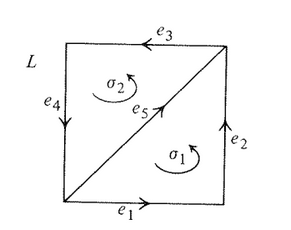

In [ ]:
from sympy import Matrix, FiniteField
from sympy.matrices.normalforms import smith_normal_form
import numpy as np

m_2 = Matrix([
    [1,  0],  # e1
    [1,  0],  # e2
    [0,  1],  # e3
    [0,  1],  # e4
    [1,  1]   # e5
])
F2 = FiniteField(2)

result = smith_normal_form(m_2, domain=F2)
result_np = np.array(result).astype(int)

print(result_np)

Concluimos que $z_2=0$ y $b_1=2$

In [ ]:
from sympy import Matrix, FiniteField
from sympy.matrices.normalforms import smith_normal_form
import numpy as np

m_1 = Matrix([
    [1, 0, 0, 1, 1],  # v1
    [1, 1, 0, 0, 0],  # v2
    [0, 1, 1, 0, 1],  # v3
    [0, 0, 1, 1, 0],  # v4
])
F2 = FiniteField(2)

result = smith_normal_form(m_1, domain=F2)
result_np = np.array(result).astype(int)

print(result_np)

Concluimos que $z_1=1$ y $b_0=3$

# Ejemplos

In [ ]:
!pip install ripser persim

## Ejemplo 1


In [ ]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt


X, _ = make_blobs(n_samples=300,
                  n_features=2,
                  centers=5,
                  random_state=558)
X = np.random.uniform(low=-1, high=1, size=(300, 2))


print(X.shape)

plt.figure()
plt.scatter(X[:,0],X[:,1])
plt.show()

In [ ]:
from ripser import Rips
from persim import plot_diagrams

rips = Rips(maxdim=1)
diagram = rips.fit_transform(X)

plt.figure()
plot_diagrams(diagram, legend=True)
plt.show()

## Ejemplo 2

https://github.com/DCDPUAEM/DCDP/blob/main/04%20Deep%20Learning/notebooks/07-Autoencoders.ipynb

In [ ]:
!gdown 1mqfspvk8kqG0hMHeiIXJ3UHIQHXLO-gv
!gdown 1Q89lbS06bdLG1N8FKHtefvrpT0XmaFRt

In [ ]:
periodic = np.loadtxt('periodic_signal.txt')
nonperiodic = np.loadtxt('nonperiodic_signal.txt')
print(f"Periodic: {periodic.shape}")
print(f"Nonperiodic: {nonperiodic.shape}")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(periodic[:500], 'b-', linewidth=0.8)
plt.subplot(1,2,2)
plt.plot(nonperiodic[:500], 'r-', linewidth=0.8)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
from scipy.spatial.distance import pdist

def takens_embedding(signal, tau, d):
    n = len(signal) - (d-1)*tau
    embedded = np.zeros((n, d))
    for i in range(d):
        embedded[:, i] = signal[i*tau : i*tau + n]
    return embedded

def analyze_signal_topology(signal, tau, d=3, label="Signal"):
    """
    Análisis topológico minimal de una señal.
    """
    # Embeddings normalizados
    embedded = takens_embedding(signal, tau, d)
    embedded = (embedded - embedded.mean(axis=0)) / embedded.std(axis=0)

    # Subsampleo (para eficiencia)
    step = max(1, len(embedded) // 300)
    embedded_sub = embedded[::step]

    # Distancias
    dists = pdist(embedded_sub)
    p90 = np.percentile(dists, 90)

    # Homología persistente
    thresh = 1.3*p90
    result = ripser(embedded_sub, maxdim=1, thresh=thresh)
    dgm0 = result['dgms'][0]
    dgm1 = result['dgms'][1]

    # Filtrar infinitos
    dgm1_finite = dgm1[dgm1[:, 1] < np.inf]

    # Análisis
    if len(dgm1_finite) > 0:
        pers = dgm1_finite[:, 1] - dgm1_finite[:, 0]  # TIEMPO DE VIDA

        # Ciclos significativos
        threshold_pers = 0.3 * pers.max()
        significant = pers > threshold_pers
        n_sig = significant.sum()

        top5 = np.sort(pers)[-5:][::-1] if len(pers) >= 5 else np.sort(pers)[::-1]

        print(f"\nH1 (1-ciclos):")
        print(f"  Total: {len(dgm1_finite)}")
        print(f"  Significativos (>30% persistencia máxima): {n_sig}")
        print(f"  Top 5 persistencias: {top5}")

        if len(top5) > 1:
            ratio = top5[0] / top5[1]
            print(f"  Ratio top1/top2: {ratio:.2f}")

    else:
        print("\nNo se detectaron 1-ciclos significativos")

    return embedded, dgm0, dgm1

In [ ]:
# ============================================================
# EJEMPLO 1: SEÑAL PERIÓDICA PURA
# ============================================================
print("\n" + "="*60)
print("EJEMPLO 1: SEÑAL PERIÓDICA")
print("="*60)

emb1, _, dgm1_1 = analyze_signal_topology(
                    periodic,
                    tau=15,
                    d=3,
                    label="SEÑAL PERIÓDICA"
                )

# ============================================================
# EJEMPLO 2: SISTEMA CAÓTICO
# ============================================================
print("\n" + "="*60)
print("EJEMPLO 2: SEÑAL IRREGULAR")
print("="*60)

emb2, _, dgm1_2 = analyze_signal_topology(
                    nonperiodic,
                    tau=10,
                    d=3,
                    label="SEÑAL CAÓTICA"
                )

# ======== GRÁFICAS ======================
fig = plt.figure(figsize=(16, 10))

# Señales temporales
ax1 = plt.subplot(2,3,1)
ax1.plot(periodic[:500], 'b-', linewidth=0.8)
ax1.set_title('Señal periódica')
ax1.set_xlabel('Tiempo')

# Embeddings Takens
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(emb1[:, 0], emb1[:, 1], color='b', s=10)
ax2.set_title('Embeddings de Takens')
ax2.set_xlabel('x(t)')
ax2.set_ylabel('x(t+tau)')
ax2.set_aspect('equal')

# Diagramas de persistencia
ax3 = plt.subplot(2, 3, 3)
plot_diagrams([dgm1_1], ax=ax3, legend=False)
ax3.set_title('Diagrama Periódica')

# Señales temporales
ax4 = plt.subplot(2, 3, 4)
ax4.plot(nonperiodic[:500], 'r-', linewidth=0.8)
ax4.set_title('Señal irregular')
ax4.set_xlabel('Tiempo')

# Embeddings Takens
ax5 = plt.subplot(2, 3, 5)
ax5.scatter(emb2[:, 0], emb2[:, 1], color='r', s=10)
ax5.set_title('Embeddings de Takens')
ax5.set_xlabel('x(t)')
ax5.set_ylabel('x(t+tau)')
ax5.set_aspect('equal')

# Diagrama de persistencia
ax6 = plt.subplot(2, 3, 6)
plot_diagrams([dgm1_2], ax=ax6, legend=False)
ax6.set_title('Diagrama irregular')


plt.tight_layout()
plt.savefig('tda_periodic_signals.png', dpi=200, bbox_inches='tight')
plt.show()
